# Temperature anomaly calculation vs. 30-year baseline

In [357]:
import pandas as pd

df = pd.read_csv("../../../../data/clean/Yashaswi/Final_Clean/temp_clean_Daily.csv", 
                    dtype={"Climate ID": "string"},
                    low_memory=False
)
stations = pd.read_csv("../../../../data/clean/Yashaswi/Final_Clean/dim_station_clean.csv")

df["Date"] = pd.to_datetime(df["Date"])
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"]   = df["Date"].dt.day

In [358]:
df.columns

Index(['Climate ID', 'Date', 'Max Temp (°C)', 'Min Temp (°C)',
       'Mean Temp (°C)', 'Heat Deg Days (°C)', 'Cool Deg Days (°C)', 'Year',
       'Month', 'Day'],
      dtype='str')

In [359]:
df.head()

,Climate ID,Date,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Year,Month,Day
0,8204020,2021-09-11,18.7,8.7,13.7,4.3,0.0,2021,9,11
1,8204020,2021-09-12,22.4,9.8,16.1,1.9,0.0,2021,9,12
2,8204020,2021-09-13,20.8,11.0,15.9,2.1,0.0,2021,9,13
3,8204020,2021-09-14,17.2,6.9,12.1,5.9,0.0,2021,9,14
4,8204020,2021-09-15,20.2,5.7,13.0,5.0,0.0,2021,9,15


In [360]:
stations.columns

Index(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID',
       'Province'],
      dtype='str')

In [361]:
df = df.rename(columns={"Climate ID": "station_id"})
stations = stations.rename(columns={"Climate ID": "station_id"})

In [362]:
df = df.merge(
    stations,
    on="station_id",
    how="left"
)

In [363]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 818993 entries, 0 to 818992
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   station_id          818993 non-null  object        
 1   Date                818993 non-null  datetime64[us]
 2   Max Temp (°C)       814288 non-null  float64       
 3   Min Temp (°C)       816921 non-null  float64       
 4   Mean Temp (°C)      818993 non-null  float64       
 5   Heat Deg Days (°C)  812218 non-null  float64       
 6   Cool Deg Days (°C)  812218 non-null  float64       
 7   Year                818993 non-null  int32         
 8   Month               818993 non-null  int32         
 9   Day                 818993 non-null  int32         
 10  Longitude (x)       818993 non-null  float64       
 11  Latitude (y)        818993 non-null  float64       
 12  Station Name        818993 non-null  str           
 13  Province            818993 non-null  str

## Check: Inspect temperature on 1st Jan each year

In [365]:
df.loc[
    (df["station_id"] == "8100300") &
    (df["Month"] == 1) &
    (df["Day"] == 1),
    ["Year", "Mean Temp (°C)"]
]

,Year,Mean Temp (°C)
10755,1995,-11.0
11120,1996,-21.8
11486,1997,-17.0
11851,1998,-16.3
12216,1999,-26.5
12581,2000,-11.3
12947,2001,0.0
13523,2004,-7.5
13889,2005,3.0
14131,2008,-9.3


## Temperature Anomaly  (30‑Year Baseline)

In [366]:
BASELINE_START = 1995
BASELINE_END   = 2025

df_baseline_src = df[
    (df["Year"] >= BASELINE_START) &
    (df["Year"] <= BASELINE_END)
]

## Compute daily climatology baseline

In [367]:
baseline = (
    df_baseline_src
    .groupby(["station_id", "Month", "Day"], as_index=False)
    ["Mean Temp (°C)"]
    .mean()
    .rename(columns={
        "Mean Temp (°C)": "Baseline Mean Temp (°C)"
    })
)
baseline.head(3)

,station_id,Month,Day,Baseline Mean Temp (°C)
0,8100300,1,1,-8.660000
1,8100300,1,2,-9.565385
2,8100300,1,3,-10.623077


## Merge baseline to full dataset

In [368]:

# Drop existing baseline/anomaly columns if they exist
df = df.drop(
    columns=["Baseline Mean Temp (°C)", "Temp Anomaly (°C)"],
    errors="ignore"
)

df = df.merge(
    baseline,
    on=["station_id", "Month", "Day"],
    how="left"
)
df.loc[
    (df["station_id"] == "8100300") &
    (df["Month"] == 1) &
    (df["Day"] == 1),
    ["Year", "Mean Temp (°C)","Baseline Mean Temp (°C)"]
]

,Year,Mean Temp (°C),Baseline Mean Temp (°C)
10755,1995,-11.0,-8.66
11120,1996,-21.8,-8.66
11486,1997,-17.0,-8.66
11851,1998,-16.3,-8.66
12216,1999,-26.5,-8.66
12581,2000,-11.3,-8.66
12947,2001,0.0,-8.66
13523,2004,-7.5,-8.66
13889,2005,3.0,-8.66
14131,2008,-9.3,-8.66


## Calculate temperature anomaly

In [369]:
df["Temp Anomaly (°C)"] = (
    df["Mean Temp (°C)"] -
    df["Baseline Mean Temp (°C)"]
)

## Quality‑assurance checks 

In [370]:
print("Missing baseline (%):",
      df["Baseline Mean Temp (°C)"].isna().mean() * 100)

Missing baseline (%): 0.0


In [371]:
df["Temp Anomaly (°C)"].describe()

count    8.189930e+05
mean    -1.388130e-18
std      3.744718e+00
min     -2.942500e+01
25%     -2.327586e+00
50%     -7.200000e-02
75%      2.281818e+00
max      2.127500e+01
Name: Temp Anomaly (°C), dtype: float64

In [372]:
df.columns

Index(['station_id', 'Date', 'Max Temp (°C)', 'Min Temp (°C)',
       'Mean Temp (°C)', 'Heat Deg Days (°C)', 'Cool Deg Days (°C)', 'Year',
       'Month', 'Day', 'Longitude (x)', 'Latitude (y)', 'Station Name',
       'Province', 'Baseline Mean Temp (°C)', 'Temp Anomaly (°C)'],
      dtype='str')

In [373]:
baseline_df = df[[
    "station_id",
    "Month",
    "Day",
    "Baseline Mean Temp (°C)"
]]
baseline_df.head()

,station_id,Month,Day,Baseline Mean Temp (°C)
0,8204020,9,11,16.54
1,8204020,9,12,15.80
2,8204020,9,13,17.14
3,8204020,9,14,15.64
4,8204020,9,15,14.30


## ✅ Step 2: Verify uniqueness (VERY important)
- ✅ Expected result: empty Series
- ❌ If not empty → conflicting baselines exist and must be resolved

In [374]:
dup_check = (
    baseline_df
    .groupby(["station_id", "Month", "Day"])["Baseline Mean Temp (°C)"]
    .nunique()
)

dup_check[dup_check > 1]

Series([], Name: Baseline Mean Temp (°C), dtype: int64)

In [375]:
baseline_df.groupby("station_id").size().describe()

count      136.000000
mean      6022.007353
std       3124.680953
min        244.000000
25%       3208.500000
50%       5528.500000
75%       8321.750000
max      11320.000000
dtype: float64

In [376]:
baseline_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 818993 entries, 0 to 818992
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   station_id               818993 non-null  object 
 1   Month                    818993 non-null  int32  
 2   Day                      818993 non-null  int32  
 3   Baseline Mean Temp (°C)  818993 non-null  float64
dtypes: float64(1), int32(2), object(1)
memory usage: 18.7+ MB


In [377]:
baseline_variation = (
    baseline_df
    .groupby(["station_id", "Month", "Day"])["Baseline Mean Temp (°C)"]
    .nunique()
)
baseline_variation[baseline_variation > 1]

Series([], Name: Baseline Mean Temp (°C), dtype: int64)

In [378]:
baseline_days_per_station = (
    baseline_df
    .drop_duplicates(["station_id", "Month", "Day"])
    .groupby("station_id")
    .size()
)

baseline_days_per_station.describe()

count    136.000000
mean     364.485294
std       15.743304
min      183.000000
25%      366.000000
50%      366.000000
75%      366.000000
max      366.000000
dtype: float64

In [379]:
baseline_unique = (
    baseline_df
    .groupby(
        ["station_id", "Month", "Day"],
        as_index=False
    )["Baseline Mean Temp (°C)"]
    .first()
)

In [380]:
baseline_unique.info()

<class 'pandas.DataFrame'>
RangeIndex: 49570 entries, 0 to 49569
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   station_id               49570 non-null  str    
 1   Month                    49570 non-null  int32  
 2   Day                      49570 non-null  int32  
 3   Baseline Mean Temp (°C)  49570 non-null  float64
dtypes: float64(1), int32(2), str(1)
memory usage: 1.5 MB


## Export Baseline per station csv

## Define and Export Temperature Anomoly table

In [381]:
bi_anomaly_table = df[
    [
        "station_id",
        "Date",
        "Baseline Mean Temp (°C)",
        "Temp Anomaly (°C)"
    ]
].copy()
bi_anomaly_table["Date"] = pd.to_datetime(bi_anomaly_table["Date"])
bi_anomaly_table["station_id"] = bi_anomaly_table["station_id"].astype(str)

In [382]:
bi_anomaly_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 818993 entries, 0 to 818992
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   station_id               818993 non-null  str           
 1   Date                     818993 non-null  datetime64[us]
 2   Baseline Mean Temp (°C)  818993 non-null  float64       
 3   Temp Anomaly (°C)        818993 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 30.5 MB


In [383]:
# Round only float columns to 4 decimal places
float_cols = bi_anomaly_table.select_dtypes(include="float").columns

bi_anomaly_table[float_cols] = bi_anomaly_table[float_cols].round(4)
float_cols = bi_anomaly_table.select_dtypes(include="float").columns
bi_anomaly_table[float_cols] = bi_anomaly_table[float_cols].astype("float32")

In [384]:
bi_anomaly_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 818993 entries, 0 to 818992
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   station_id               818993 non-null  str           
 1   Date                     818993 non-null  datetime64[us]
 2   Baseline Mean Temp (°C)  818993 non-null  float32       
 3   Temp Anomaly (°C)        818993 non-null  float32       
dtypes: datetime64[us](1), float32(2), str(1)
memory usage: 24.2 MB


### Check - BI anamoly table

In [385]:
bi_anomaly_table.groupby(
    ["station_id", bi_anomaly_table["Date"].dt.month, bi_anomaly_table["Date"].dt.day]
)["Baseline Mean Temp (°C)"].nunique().describe()

count    49570.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: Baseline Mean Temp (°C), dtype: float64

In [386]:
bi_anomaly_table["Date"].min(), bi_anomaly_table["Date"].max()

(Timestamp('1995-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [387]:
bi_anomaly_table["Date"].dt.year.describe()

count    818993.000000
mean       2013.807396
std           8.259403
min        1995.000000
25%        2008.000000
50%        2015.000000
75%        2021.000000
max        2025.000000
Name: Date, dtype: float64

In [388]:
bi_anomaly_table["Date"].dt.year.value_counts().sort_index()

Date
1995    11402
1996    11615
1997    11207
1998    11772
1999    11842
2000    12999
2001    14118
2002    14400
2003    16297
2004    18725
2005    20255
2006    23383
2007    22904
2008    22344
2009    23567
2010    24198
2011    24790
2012    27813
2013    29779
2014    31410
2015    32476
2016    32348
2017    33214
2018    36092
2019    40556
2020    40328
2021    40475
2022    43798
2023    45350
2024    45227
2025    44309
Name: count, dtype: int64

In [389]:
# Optimize types
bi_anomaly_table["station_id"] = bi_anomaly_table["station_id"].astype("category")

# Reduce precision
bi_anomaly_table["Temp Anomaly (°C)"] = bi_anomaly_table["Temp Anomaly (°C)"].round(2)
bi_anomaly_table["Baseline Mean Temp (°C)"] = bi_anomaly_table["Baseline Mean Temp (°C)"].round(2)

# Export
bi_anomaly_table.to_parquet(
    r"../../../../data/clean/Yashaswi/Final_Clean/temperature_anomalies.parquet",
    index=False
)

## ✅ 1. Check if each station has only ONE row per date (most important)
✅ Interpretation

- False → ✅ each station has only one row per date
- True → ❌ duplicates exist (problem)

In [391]:
bi_anomaly_table.duplicated(subset=["station_id", "Date"]).any()

np.False_

In [392]:
bi_anomaly_table.duplicated(
    subset=["station_id", "Date"]
).sum()

np.int64(0)

In [393]:
baseline_check = (
    bi_anomaly_table
    .groupby(["station_id", "Date"])["Baseline Mean Temp (°C)"]
    .nunique()
)

baseline_check[baseline_check > 1]

Series([], Name: Baseline Mean Temp (°C), dtype: int64)

## Monthly anomalies

In [394]:
monthly_anomaly = (
    df.groupby(["station_id", "Year", "Month"])["Temp Anomaly (°C)"]
      .mean()
      .reset_index()
)

## Seasonal anomalies

In [395]:
season_map = {
    12:"Winter", 1:"Winter", 2:"Winter",
     3:"Spring", 4:"Spring", 5:"Spring",
     6:"Summer", 7:"Summer", 8:"Summer",
     9:"Fall",  10:"Fall",  11:"Fall"
}

df["Season"] = df["Month"].map(season_map)

seasonal_anomaly = (
    df.groupby(["station_id", "Year", "Season"])["Temp Anomaly (°C)"]
      .mean()
      .reset_index()
)
seasonal_anomaly.head()

,station_id,Year,Season,Temp Anomaly (°C)
0,8100300,1995,Fall,-0.246746
1,8100300,1995,Spring,-1.157469
2,8100300,1995,Summer,0.618825
3,8100300,1995,Winter,-1.847593
4,8100300,1996,Fall,-0.948944


# Long‑term warming trends using temperature anomalies
- Goal
Quantify and visualize warming trends over time:

per station
per province
nationally (optional)

All trends are based on anomalies, not raw temperature (best practice).

In [397]:
required_cols = [
    "station_id", "Date", "Year",
    "Temp Anomaly (°C)", "Province"
]

missing = [c for c in required_cols if c not in df.columns]
missing

[]

## Caluclate Monthly Station anomalies and warming/cooling trends

In [439]:
monthly_station_anomaly = (
    df
    .groupby(["station_id", "Year", "Month"], as_index=False)
    ["Temp Anomaly (°C)"]
    .mean()
)
monthly_station_anomaly.head()

,station_id,Year,Month,Temp Anomaly (°C)
0,8100300,1995,1,1.842241
1,8100300,1995,2,-4.074798
2,8100300,1995,3,0.071257
3,8100300,1995,4,-2.884271
4,8100300,1995,5,-0.715095


## STEP 2 — create a time index (important for regression)

In [440]:
monthly_station_anomaly["time"] = (
    monthly_station_anomaly["Year"] +
    (monthly_station_anomaly["Month"] - 1) / 12
)

In [441]:
monthly_station_anomaly.groupby(["station_id", "Month"]).size().describe()

count    1626.000000
mean       17.284748
std         8.815551
min         1.000000
25%         9.000000
50%        16.000000
75%        25.000000
max        31.000000
dtype: float64

## STEP 3 — define SAFE trend function (monthly)

In [442]:
import numpy as np

def safe_trend_monthly(g):
    g = g.dropna(subset=["time", "Temp Anomaly (°C)"])

    # ✅ at least 24 MONTHS (not years)
    if len(g) < 2:
        return np.nan

    slope, _ = np.polyfit(g["time"], g["Temp Anomaly (°C)"], 1)
    
    return slope * 10  # °C / decade

## STEP 4 — compute monthly-based trend per station

In [443]:
monthly_station_trends = (
    monthly_station_anomaly
    .groupby(["station_id", "Month"])
    .apply(safe_trend_monthly)
    .reset_index(name="Trend (°C / decade)")
)
monthly_station_trends.head()

,station_id,Month,Trend (°C / decade)
0,8100300,1,0.874749
1,8100300,2,0.522973
2,8100300,3,0.431158
3,8100300,4,0.448549
4,8100300,5,0.143763


In [444]:
monthly_counts = (
    monthly_station_anomaly
    .groupby(["station_id", "Month"])
    .size()
    .reset_index(name="n_years")
)

In [452]:
monthly_trends_by_month = monthly_trends_by_month.merge(
    monthly_counts,
    on=["station_id", "Month"],
    how="left"
)
monthly_trends_by_month = monthly_trends_by_month[
    ["station_id", "Month", "Trend (°C / decade)", "n_years"]
]
monthly_trends_by_month.head()

,station_id,Month,Trend (°C / decade),n_years
0,8100300,1,0.874749,26
1,8100300,2,0.522973,26
2,8100300,3,0.431158,24
3,8100300,4,0.448549,26
4,8100300,5,0.143763,26


In [453]:
monthly_trends_by_month.to_parquet(
    r"../../../../data/clean/Yashaswi/Final_Clean/Station_monthly_trends.parquet",
    index=False
)

In [447]:
monthly_trends_clean = monthly_trends_by_month.dropna(
    subset=["Trend (°C / decade)"]
)

In [448]:
monthly_trends_clean.info()

<class 'pandas.DataFrame'>
Index: 444 entries, 0 to 1529
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   station_id           444 non-null    str    
 1   Month                444 non-null    int32  
 2   Trend (°C / decade)  444 non-null    float64
 3   n_years              444 non-null    int64  
dtypes: float64(1), int32(1), int64(1), str(1)
memory usage: 18.7 KB


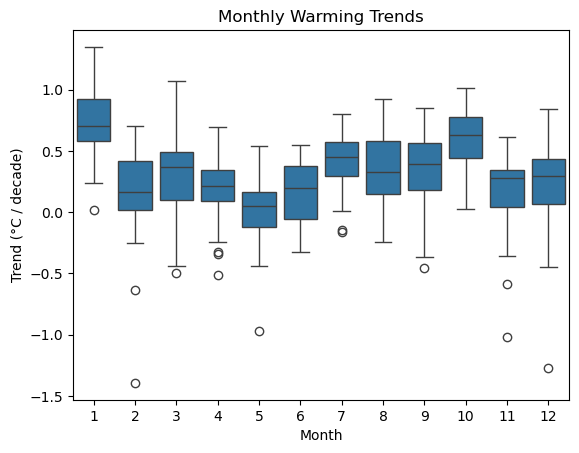

In [449]:
import seaborn as sns

sns.boxplot(
    data=monthly_trends_clean,
    x="Month",
    y="Trend (°C / decade)"
)

plt.title("Monthly Warming Trends")
plt.show()

# Heatwave Detection Using Temperature Anomalies
- Definition (clear & climate‑standard)
We will define a heatwave as:

≥ 3 consecutive days where
Daily temperature anomaly ≥ +2.0 °C
relative to the 30‑year station baseline

✅ Station‑specific
✅ Baseline‑relative
✅ Robust across regions
(Thresholds can be adjusted later.)

In [454]:
df = df.sort_values(["station_id", "Date"]).reset_index(drop=True)
df.head(3)

,station_id,Date,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Year,Month,Day,Longitude (x),Latitude (y),Station Name,Province,Baseline Mean Temp (°C),Temp Anomaly (°C),Season
0,8100300,1995-01-01,-8.0,-14.0,-11.0,29.0,0.0,1995,1,1,-67.72,46.71,AROOSTOOK,NEW BRUNSWICK,-8.660000,-2.340000,Winter
1,8100300,1995-01-02,-4.0,-9.0,-6.5,24.5,0.0,1995,1,2,-67.72,46.71,AROOSTOOK,NEW BRUNSWICK,-9.565385,3.065385,Winter
2,8100300,1995-01-03,-6.0,-10.5,-8.3,26.3,0.0,1995,1,3,-67.72,46.71,AROOSTOOK,NEW BRUNSWICK,-10.623077,2.323077,Winter


## Flag heatwave‑candidate days

In [455]:
HEATWAVE_THRESHOLD = 2.0  # °C anomaly

df["hw_day"] = df["Temp Anomaly (°C)"] >= HEATWAVE_THRESHOLD

## Identify consecutive heatwave runs per station

In [456]:
# Start a new group when hw_day changes OR station changes
df["hw_group"] = (
    df["hw_day"]
    .ne(df["hw_day"].shift())
    | df["station_id"].ne(df["station_id"].shift())
).cumsum()

## Extract valid heatwave events (≥ 3 days)

In [457]:
heatwaves = (
    df[df["hw_day"]]
    .groupby(["station_id", "hw_group"])
    .agg(
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        duration_days=("Date", "count"),
        mean_anomaly=("Temp Anomaly (°C)", "mean"),
        max_anomaly=("Temp Anomaly (°C)", "max")
    )
    .reset_index()  # ✅ DO NOT drop index
)
heatwaves = heatwaves[heatwaves["duration_days"] >= 3]

In [458]:
heatwaves = heatwaves.drop(
    columns=[c for c in heatwaves.columns 
             if c in ["Latitude", "Longitude", "Province", "CSDNAME"]],
    errors="ignore"
)

In [459]:

heatwaves = heatwaves.merge(
    df[["station_id", "Latitude (y)", "Longitude (x)", "Province"]]
      .drop_duplicates(),
    on="station_id",
    how="left"
)
heatwaves.head()

,station_id,hw_group,start_date,end_date,duration_days,mean_anomaly,max_anomaly,Latitude (y),Longitude (x),Province
0,8100300,4,1995-01-13,1995-01-25,13,9.660637,18.404000,46.71,-67.72,NEW BRUNSWICK
1,8100300,14,1995-03-13,1995-03-19,7,4.779635,6.195833,46.71,-67.72,NEW BRUNSWICK
2,8100300,16,1995-03-21,1995-03-23,3,5.663889,6.395833,46.71,-67.72,NEW BRUNSWICK
3,8100300,18,1995-05-12,1995-05-14,3,4.146667,4.616000,46.71,-67.72,NEW BRUNSWICK
4,8100300,20,1995-05-31,1995-06-03,4,4.324038,6.500000,46.71,-67.72,NEW BRUNSWICK


In [464]:
import pandas as pd

heatwaves["start_date"] = pd.to_datetime(heatwaves["start_date"])
heatwaves["end_date"] = pd.to_datetime(heatwaves["end_date"])

heatwaves_clean = heatwaves[
    [
        "station_id",
        "hw_group",
        "start_date",
        "end_date",
        "duration_days",
        "mean_anomaly",
        "max_anomaly",
    ]
]

In [465]:
heatwaves_clean.head()

,station_id,hw_group,start_date,end_date,duration_days,mean_anomaly,max_anomaly
0,8100300,4,1995-01-13,1995-01-25,13,9.660637,18.404000
1,8100300,14,1995-03-13,1995-03-19,7,4.779635,6.195833
2,8100300,16,1995-03-21,1995-03-23,3,5.663889,6.395833
3,8100300,18,1995-05-12,1995-05-14,3,4.146667,4.616000
4,8100300,20,1995-05-31,1995-06-03,4,4.324038,6.500000


In [467]:
heatwaves_clean["start_date"].min(), \
heatwaves_clean["start_date"].max()

(Timestamp('1995-01-02 00:00:00'), Timestamp('2025-12-29 00:00:00'))

## Export Heatwaves file

In [468]:
heatwaves_clean.to_parquet(
    r"../../../../data/clean/Yashaswi/Final_Clean/heatwaves_clean.parquet",
    index=False
)

## Heatwave frequency analysis

In [469]:
heatwaves["Year"] = heatwaves["start_date"].dt.year

station_hw_freq = (
    heatwaves.groupby(["station_id", "Year"])
    .size()
    .reset_index(name="heatwave_count")
)

In [470]:
province_hw_freq = (
    heatwaves.groupby(["Province", "Year"])
    .size()
    .reset_index(name="heatwave_count")
)
province_hw_freq.info()

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Province        124 non-null    str  
 1   Year            124 non-null    int32
 2   heatwave_count  124 non-null    int64
dtypes: int32(1), int64(1), str(1)
memory usage: 4.7 KB


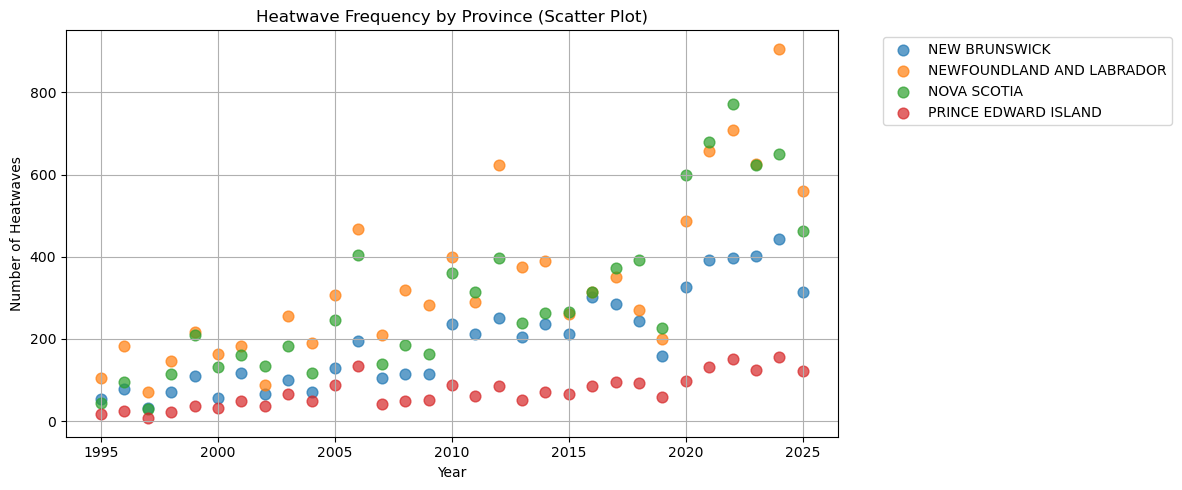

In [471]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

for province in province_hw_freq["Province"].unique():
    data = province_hw_freq[province_hw_freq["Province"] == province]
    
    plt.scatter(
        data["Year"],
        data["heatwave_count"],
        s=60,
        alpha=0.7,
        label=province
    )

plt.xlabel("Year")
plt.ylabel("Number of Heatwaves")
plt.title("Heatwave Frequency by Province (Scatter Plot)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [475]:
stations_per_province = (
    heatwaves[["Province", "station_id"]]
    .drop_duplicates()
    .groupby("Province")
    .size()
    .reset_index(name="num_stations")
)

stations_per_province

,Province,num_stations
0,NEW BRUNSWICK,27
1,NEWFOUNDLAND AND LABRADOR,51
2,NOVA SCOTIA,50
3,PRINCE EDWARD ISLAND,8


In [476]:
events_per_station = (
    heatwaves
    .groupby(["Province", "station_id"])
    .size()
    .reset_index(name="heatwave_events")
)
events_per_station.head()

,Province,station_id,heatwave_events
0,NEW BRUNSWICK,8100300,378
1,NEW BRUNSWICK,8100467,387
2,NEW BRUNSWICK,8100468,1
3,NEW BRUNSWICK,8100506,92
4,NEW BRUNSWICK,8100885,280


## Heatwave intensity metrics

In [477]:
heatwaves[[
    "duration_days",
    "mean_anomaly",
    "max_anomaly"
]].describe()

,duration_days,mean_anomaly,max_anomaly
count,28173.000000,28173.000000,28173.000000
mean,4.705001,4.759685,6.827130
std,2.532097,1.493799,2.612855
min,3.000000,2.045968,2.103226
25%,3.000000,3.653083,4.886207
50%,4.000000,4.498408,6.380000
75%,5.000000,5.604365,8.296667
max,35.000000,13.931407,21.275000


# Trend in heatwaves
- Are heatwaves becoming more frequent/longer?

- Interpretation:

↑ frequency → more frequent blocking patterns
↑ duration → more persistent extremes (higher risk)

## Event frequency per year

In [478]:
annual_hw_count = (
    heatwaves
    .groupby("Year")
    .size()
    .reset_index(name="heatwave_events")
)

annual_hw_count.head()

,Year,heatwave_events
0,1995,222
1,1996,380
2,1997,138
3,1998,352
4,1999,577


In [479]:
heatwaves.groupby("Year")["station_id"].nunique().head()

Year
1995    33
1996    34
1997    34
1998    33
1999    35
Name: station_id, dtype: int64

## Trend (events per decade)

In [480]:
import numpy as np

slope_events_per_decade = (
    np.polyfit(
        annual_hw_count["Year"],
        annual_hw_count["heatwave_events"],
        1
    )[0] * 10
)

slope_events_per_decade

np.float64(506.91935483871595)

# Viz

## Total heatwave events per year (all stations)
- Purpose: National exposure / climate burden
⚠️ Reminder: this is not per station — it is total exposure.

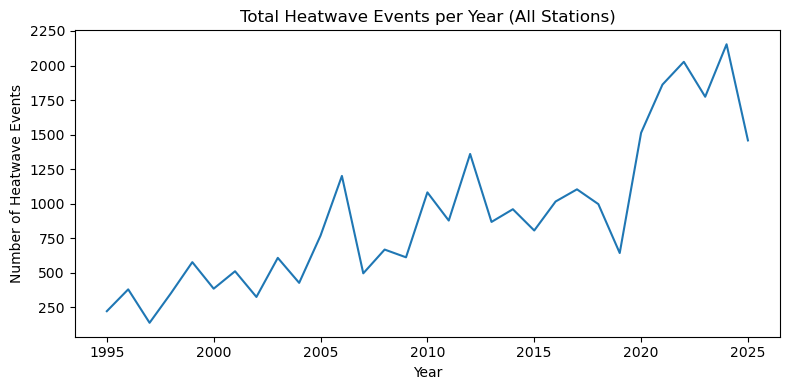

In [482]:
annual_hw_events = (
    heatwaves.groupby("Year")
    .size()
    .reset_index(name="Total Heatwave Events")
)

plt.figure(figsize=(8,4))
plt.plot(annual_hw_events["Year"], annual_hw_events["Total Heatwave Events"])
plt.title("Total Heatwave Events per Year (All Stations)")
plt.xlabel("Year")
plt.ylabel("Number of Heatwave Events")
plt.tight_layout()
plt.show()

## Average heatwaves per station per year (best practice trend)
- Purpose: Proper climate signal 

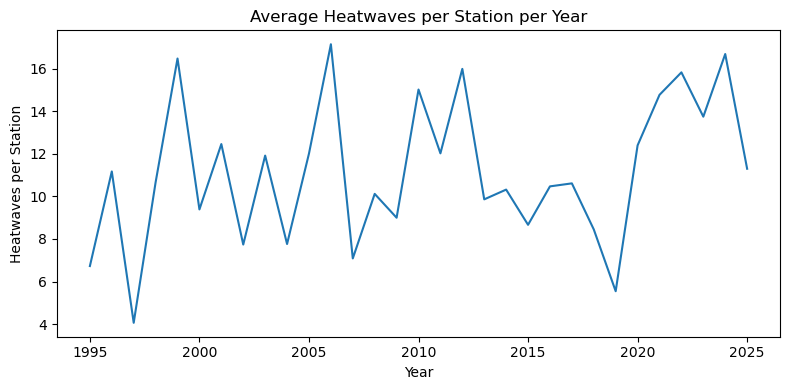

In [483]:
avg_hw_per_station = (
    heatwaves
    .groupby(["station_id", "Year"])
    .size()
    .groupby("Year")
    .mean()
    .reset_index(name="Avg Heatwaves per Station")
)

plt.figure(figsize=(8,4))
plt.plot(avg_hw_per_station["Year"], avg_hw_per_station["Avg Heatwaves per Station"])
plt.title("Average Heatwaves per Station per Year")
plt.xlabel("Year")
plt.ylabel("Heatwaves per Station")
plt.tight_layout()
plt.show()

## Heatwave duration trend
- ✅ Rising duration = more dangerous extremes.

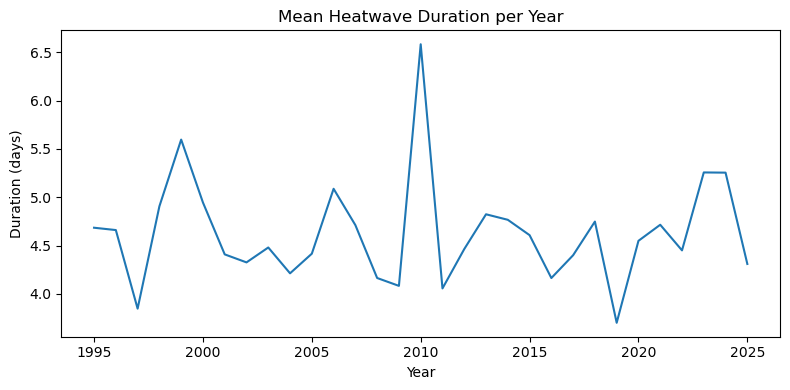

In [484]:
mean_hw_duration = (
    heatwaves.groupby("Year")["duration_days"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,4))
plt.plot(mean_hw_duration["Year"], mean_hw_duration["duration_days"])
plt.title("Mean Heatwave Duration per Year")
plt.xlabel("Year")
plt.ylabel("Duration (days)")
plt.tight_layout()
plt.show()

#  Province‑level temperature anomalies

In [485]:
province_annual_anomaly = (
    df.groupby(["Province", "Year"], as_index=False)
      ["Temp Anomaly (°C)"]
      .mean()
)

## Rank provinces by warming trend

In [486]:
import numpy as np

province_trends = (
    province_annual_anomaly
    .groupby("Province")
    .apply(
        lambda g: np.polyfit(
            g["Year"], g["Temp Anomaly (°C)"], 1
        )[0] * 10   # °C per decade
    )
    .reset_index(name="Warming Rate (°C / decade)")
    .sort_values("Warming Rate (°C / decade)", ascending=False)
)

province_trends

,Province,Warming Rate (°C / decade)
3,PRINCE EDWARD ISLAND,0.348994
1,NEWFOUNDLAND AND LABRADOR,0.251060
2,NOVA SCOTIA,0.235465
0,NEW BRUNSWICK,0.158325


# Temperature trend estimation: Linear & Polynomial fits
- Linear & Polynomial Fits Using Anomalies
- Scope (explicit and correct)

Region: Atlantic Canada
Provinces: NS, NB, NL, PEI
Variable: Temperature anomalies (°C)
Baseline: Your 30‑year station‑level baseline
Temporal resolution: Annual means (required for trends)

##  Define Atlantic Canada subset

In [487]:
atlantic_provinces = [
    "NOVA SCOTIA",
    "NEW BRUNSWICK",
    "NEWFOUNDLAND AND LABRADOR",
    "PRINCE EDWARD ISLAND"
]

df_atlantic = df[df["Province"].isin(atlantic_provinces)].copy()

## Step 2 — Compute Atlantic‑wide annual mean anomaly

In [488]:
atlantic_annual_anomaly = (
    df_atlantic
    .groupby("Year")["Temp Anomaly (°C)"]
    .mean()
    .reset_index()
)

# PART A — Linear trend (primary result)
- ✅ Step 3 — Linear regression (°C per decade)
- ✅ Interpretation

Atlantic Canada has warmed at a rate of X °C per decade,
relative to the chosen 30‑year baseline.

This is the number you report in text, tables, and abstracts.

In [489]:
atlantic_annual_anomaly.head(3)

,Year,Temp Anomaly (°C)
0,1995,-1.050455
1,1996,-0.416414
2,1997,-1.477448


In [490]:
import numpy as np

slope, intercept = np.polyfit(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"],
    1
)

atlantic_trend_c_per_decade = slope * 10
atlantic_trend_c_per_decade

np.float64(0.23557442243138968)

## ✅ Step 4 — Plot linear trend

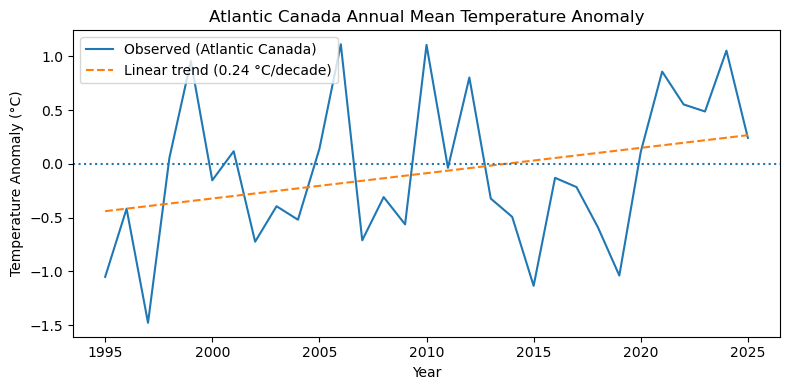

In [491]:
import numpy as np
import matplotlib.pyplot as plt

# Recompute linear regression (safe even if already done)
slope, intercept = np.polyfit(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"],
    1
)

trend_per_decade = slope * 10

# Plot
plt.figure(figsize=(8,4))

plt.plot(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"],
    label="Observed (Atlantic Canada)"
)

plt.plot(
    atlantic_annual_anomaly["Year"],
    slope * atlantic_annual_anomaly["Year"] + intercept,
    linestyle="--",
    label=f"Linear trend ({trend_per_decade:.2f} °C/decade)"
)

plt.axhline(0, linestyle=":")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Atlantic Canada Annual Mean Temperature Anomaly")
plt.tight_layout()
plt.show()

In [492]:
len(df)

818993

In [493]:
df["Province"].value_counts()

Province
NEWFOUNDLAND AND LABRADOR    310108
NOVA SCOTIA                  281710
NEW BRUNSWICK                166292
PRINCE EDWARD ISLAND          60883
Name: count, dtype: int64

# 🟧 PART B — Polynomial fit (secondary / diagnostic)
-Polynomial fits are not a replacement for linear trends.
They are used to explore non‑linearity or acceleration.

## Step 5 — Quadratic (2nd‑order) fit

In [494]:
coeffs_2 = np.polyfit(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"],
    2
)

poly2 = np.poly1d(coeffs_2)

## Step 6 — Compare linear vs polynomial fits

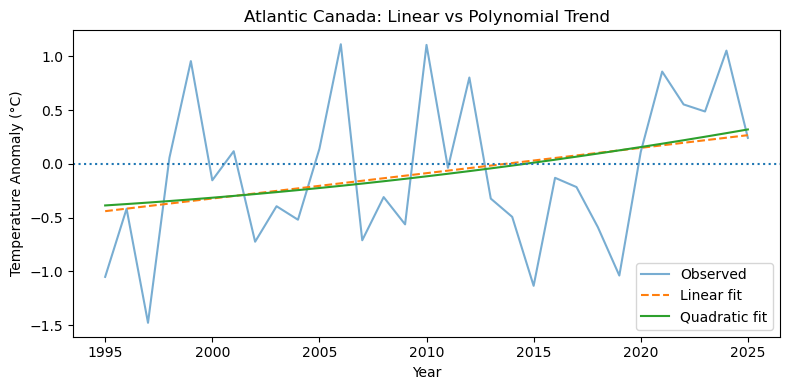

In [495]:
plt.figure(figsize=(8,4))

plt.plot(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"],
    label="Observed",
    alpha=0.6
)

plt.plot(
    atlantic_annual_anomaly["Year"],
    slope * atlantic_annual_anomaly["Year"] + intercept,
    linestyle="--",
    label="Linear fit"
)

plt.plot(
    atlantic_annual_anomaly["Year"],
    poly2(atlantic_annual_anomaly["Year"]),
    label="Quadratic fit"
)

plt.axhline(0, linestyle=":")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Atlantic Canada: Linear vs Polynomial Trend")
plt.tight_layout()
plt.show()

## 🟩 PART C — Province‑level linear trends (recommended)
This answers:

“Which Atlantic provinces are warming fastest?”

In [496]:
province_annual_anomaly = (
    df_atlantic
    .groupby(["Province", "Year"])["Temp Anomaly (°C)"]
    .mean()
    .reset_index()
)

province_trends = (
    province_annual_anomaly
    .groupby("Province")
    .apply(
        lambda g: np.polyfit(
            g["Year"],
            g["Temp Anomaly (°C)"],
            1
        )[0] * 10
    )
    .reset_index(name="Trend (°C / decade)")
    .sort_values("Trend (°C / decade)", ascending=False)
)

province_trends

,Province,Trend (°C / decade)
3,PRINCE EDWARD ISLAND,0.348994
1,NEWFOUNDLAND AND LABRADOR,0.251060
2,NOVA SCOTIA,0.235465
0,NEW BRUNSWICK,0.158325


Bottom‑line interpretation of the plot

Atlantic Canada has experienced sustained regional warming since the mid‑1990s, with recent decades dominated by positive temperature anomalies. A linear trend adequately captures the long‑term warming signal, while year‑to‑year variability reflects natural climate fluctuations.

## Provincial insights


### 🔥 Prince Edward Island (fastest warming)

~0.35 °C per decade
Roughly 1 °C of warming over ~30 years
Small land area + maritime influence → strong sensitivity

✅ This is a notable and policy‑relevant signal.


### 🌊 Newfoundland and Labrador

~0.25 °C per decade
Strong regional warming despite North Atlantic variability
Likely influenced by:

ocean circulation changes,
reduced cold extremes.





### 🌬️ Nova Scotia

~0.24 °C per decade
Consistent warming, moderated by strong marine influence

### 🌲 New Brunswick (slowest, but still warming)

~0.14 °C per decade
Still clearly positive — no province shows cooling

✅ Important point:
Lower does not mean negligible — this is still significant warming over multi‑decadal periods.